Dados carregados com sucesso!

--- Amostra dos Dados ---


,ID,Data Cadastro,Produto,Data Venda,Categoria,Preço Unit.,Qtd,Valor Total,Cidade,Vendedor,Forma de Pagamento,Status,Dias em Estoque
0,1,2025-11-26,Notebook Gamer,2026-01-20,Eletrônicos,4840.51,4,19362.04,Fortaleza,Bruno,Pix,Em Trânsito,55
1,2,2025-12-06,Headset,2025-12-29,Acessórios,120.56,2,241.12,Fortaleza,Daniel,Crédito,Entregue,23
2,3,2025-11-29,Lâmpada Smart,2025-12-03,Casa Inteligente,41.10,5,205.50,Rio de Janeiro,Bruno,Pix,Entregue,4
3,4,2025-11-04,Mouse Sem Fio,2025-12-08,Acessórios,99.45,5,497.25,Natal,Fabio,Boleto,Entregue,34
4,5,2025-08-18,Webcam,2025-12-26,Acessórios,234.34,3,703.02,Rio de Janeiro,Bruno,Pix,Entregue,130



Total de Vendas Analisadas: 1000


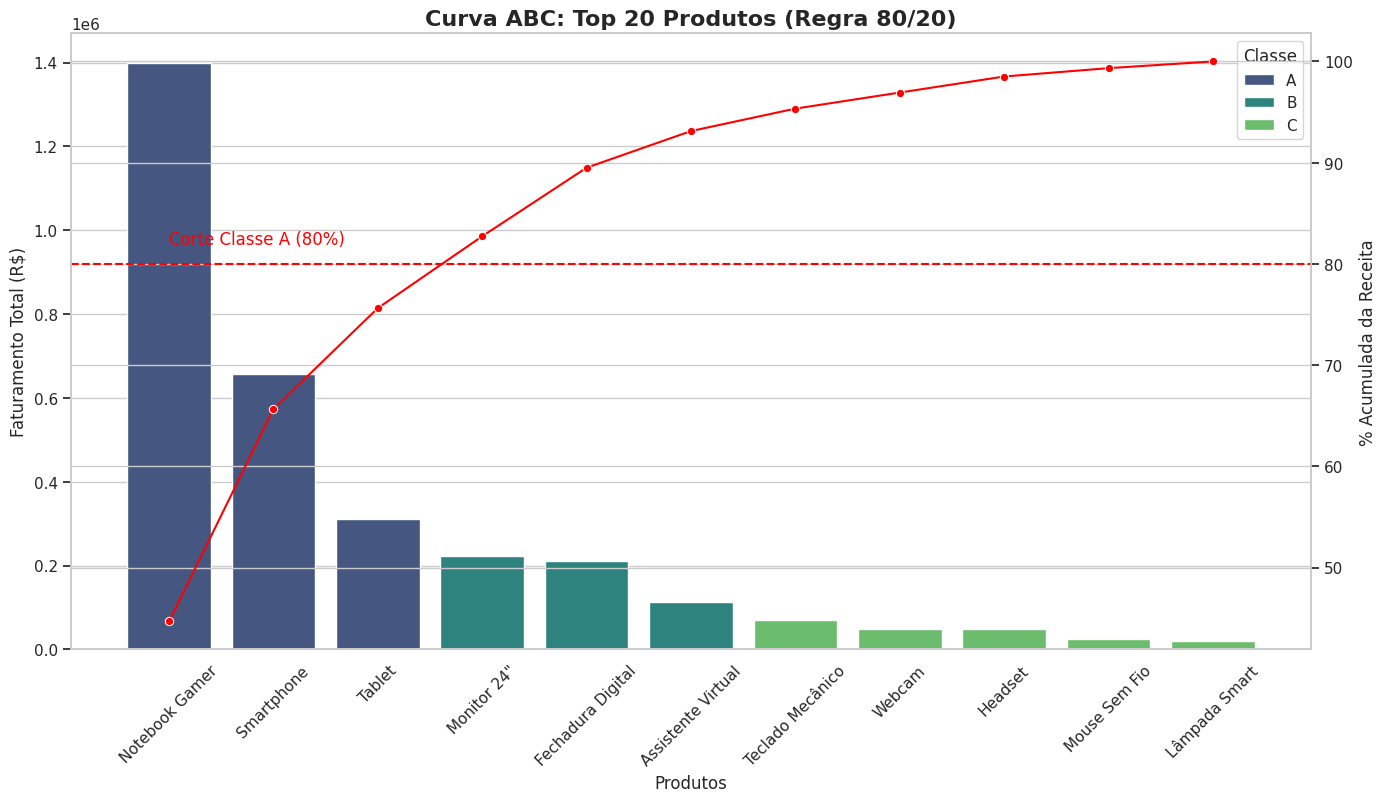

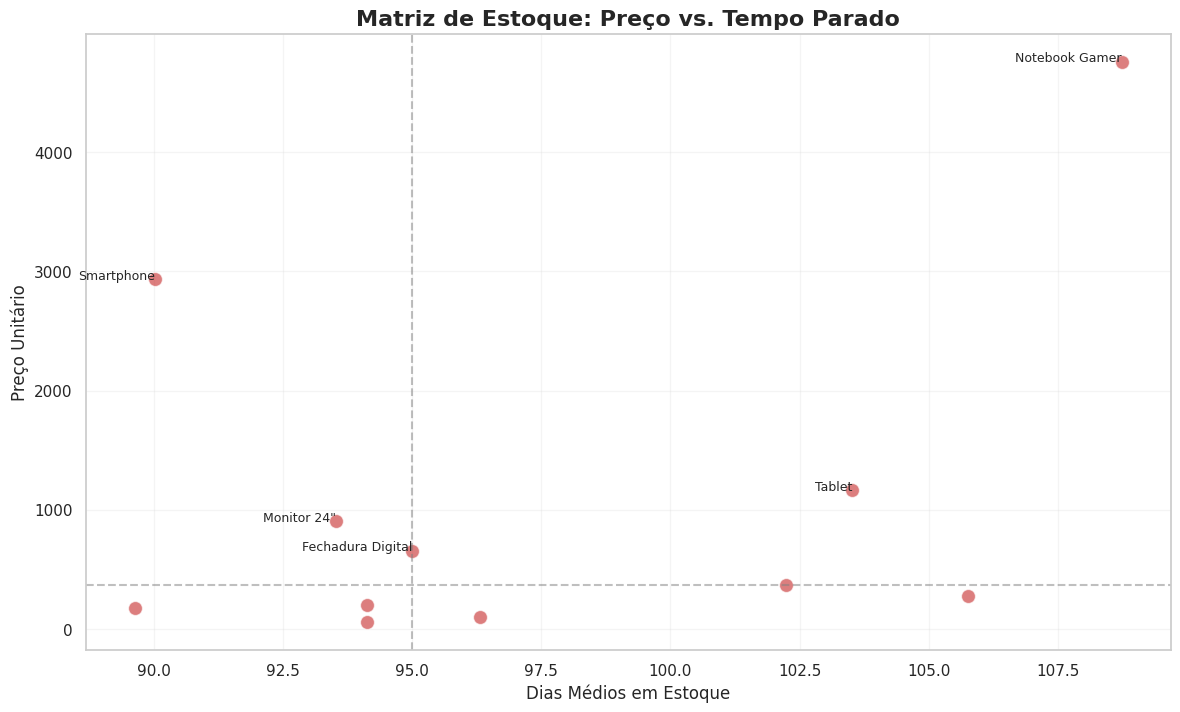

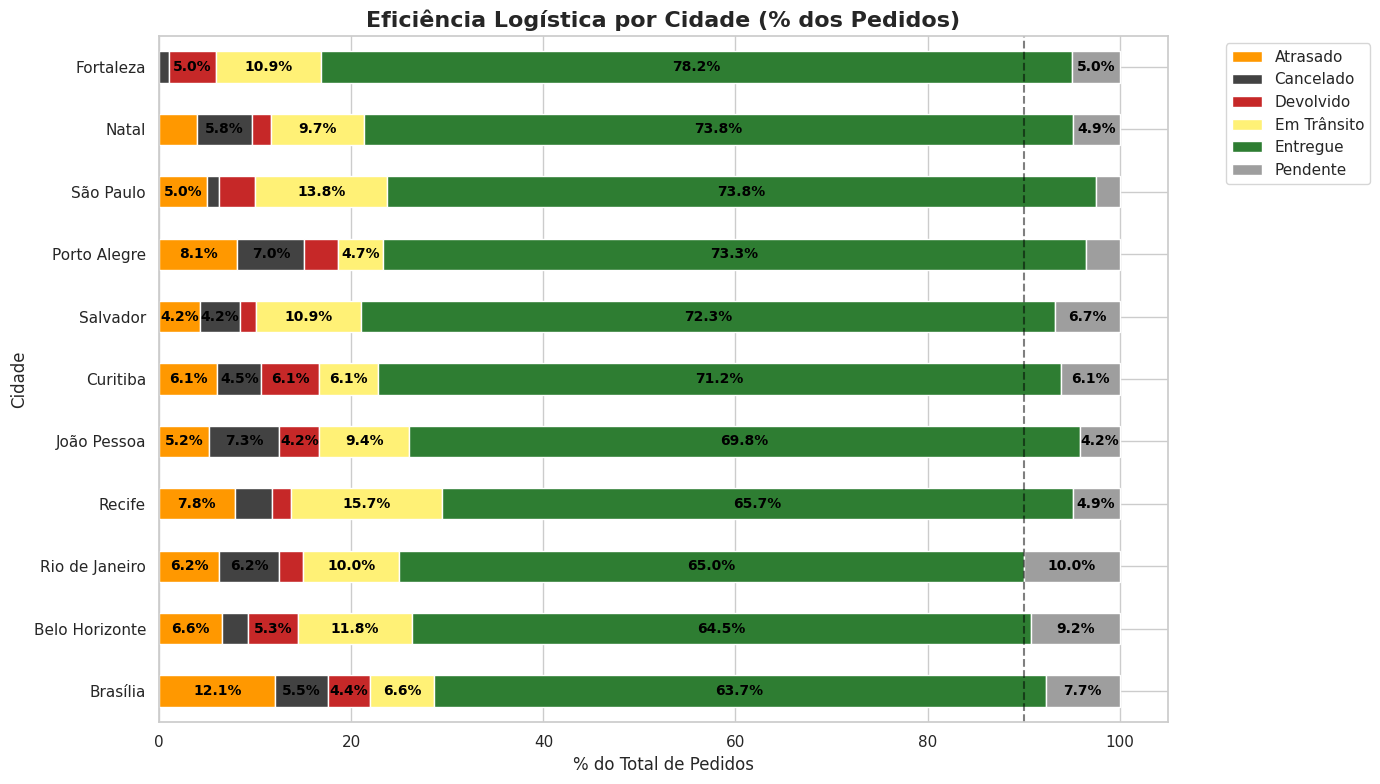

In [15]:
# ==============================================================================
# PROJETO TECHSTORE: ANÁLISE ESTRATÉGICA DE VAREJO
# Autoria: Danielly NUnes
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de Estilo Visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# ==============================================================================
# 1. CARREGAMENTO E PREPARAÇÃO (ETL)
# ==============================================================================

# Carregando os dados gerados pelo seu script
try:
    df = pd.read_csv('vendas_techstore.csv')
    print("Dados carregados com sucesso!")
except FileNotFoundError:
    print("Erro: Arquivo 'vendas_techstore.csv' não encontrado.")

# --- DATA CLEANING & TYPE CASTING ---

# Conversão de Datas
df['Data Venda'] = pd.to_datetime(df['Data Venda'], format='%d/%m/%Y')
df['Data Cadastro'] = pd.to_datetime(df['Data Cadastro'], format='%d/%m/%Y')

# Feature Engineering: Recalculando Dias em Estoque
df['Dias em Estoque'] = (df['Data Venda'] - df['Data Cadastro']).dt.days

print("\n--- Amostra dos Dados ---")
display(df.head())
print(f"\nTotal de Vendas Analisadas: {df.shape[0]}")

# ==============================================================================
# 2. ANÁLISE DE PARETO (CURVA ABC)
# ==============================================================================

# Agrupamento por Produto
df_pareto = df.groupby('Produto')['Valor Total'].sum().sort_values(ascending=False).reset_index()

# Cálculo das porcentagens acumuladas
df_pareto['% Acumulada'] = (df_pareto['Valor Total'].cumsum() / df_pareto['Valor Total'].sum()) * 100

# Classificação ABC
def classificar_abc(perc):
    if perc <= 80: return 'A'      # 80% da Receita
    elif perc <= 95: return 'B'    # +15% da Receita
    else: return 'C'               # 5% finais

df_pareto['Classe'] = df_pareto['% Acumulada'].apply(classificar_abc)

# Visualização
plt.figure(figsize=(16, 8))
ax1 = sns.barplot(x='Produto', y='Valor Total', data=df_pareto.head(20), hue='Classe', dodge=False, palette='viridis')
ax2 = ax1.twinx()
sns.lineplot(x='Produto', y='% Acumulada', data=df_pareto.head(20), color='red', marker='o', ax=ax2)

plt.title('Curva ABC: Top 20 Produtos (Regra 80/20)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Produtos')
ax1.set_ylabel('Faturamento Total (R$)')
ax2.set_ylabel('% Acumulada da Receita')
ax2.axhline(80, color='red', linestyle='--')
ax2.text(0, 82, 'Corte Classe A (80%)', color='red')
ax1.tick_params(axis='x', rotation=45)
plt.show()

# ==============================================================================
# 3. MATRIZ DE ESTOQUE (GIRO x VALOR)
# ==============================================================================

plt.figure(figsize=(14, 8))

# O Gráfico
# size='Preço Unit.' faz as bolinhas mais caras ficarem maiores
sns.scatterplot(
    data=df_estoque,
    x='Dias em Estoque',
    y='Preço Unit.',
    color='#C62828',
    alpha=0.6,
    s=100
)

# LINHAS DE CORTE (QUADRANTES)
# Usando a mediana para traçar a linha do "meio termo"
media_dias = df_estoque['Dias em Estoque'].median()
media_preco = df_estoque['Preço Unit.'].median()

plt.axvline(media_dias, color='gray', linestyle='--', alpha=0.5) # Linha Vertical
plt.axhline(media_preco, color='gray', linestyle='--', alpha=0.5) # Linha Horizontal


# Design
plt.title('Matriz de Estoque: Preço vs. Tempo Parado', fontsize=16, fontweight='bold')
plt.xlabel('Média de Dias em Estoque (Lentidão)', fontsize=12)
plt.ylabel('Preço Unitário (Impacto Financeiro)', fontsize=12)
plt.grid(True, alpha=0.2)

# Adicionar nomes nos pontos mais extremos
# Pega os 5 produtos mais críticos
produtos_criticos = df_estoque.sort_values(by=['Preço Unit.', 'Dias em Estoque'], ascending=False).head(5)

for i in range(len(produtos_criticos)):
    plt.text(
        produtos_criticos.iloc[i]['Dias em Estoque'],
        produtos_criticos.iloc[i]['Preço Unit.'],
        produtos_criticos.iloc[i]['Produto'],
        fontsize=9,
        ha='right'
    )

plt.title('Matriz de Estoque: Preço vs. Tempo Parado', fontsize=16, fontweight='bold')
plt.xlabel('Dias Médios em Estoque')
plt.ylabel('Preço Unitário')
plt.show()

# ==============================================================================
# 4. ANÁLISE LOGÍSTICA (GARGALOS POR REGIÃO)
# ==============================================================================

# Crosstab normalizado
df_logistica = pd.crosstab(df['Cidade'], df['Status'], normalize='index') * 100

# Ordena por sucesso
if 'Entregue' in df_logistica.columns:
    df_logistica = df_logistica.sort_values('Entregue', ascending=True)

# --- MAPA DE CORES  ---
cores_map = {
    'Entregue': '#2E7D32',    # Verde Escuro
    'Em Trânsito': '#FFF176', # Amarelo
    'Pendente': '#9E9E9E',    # Cinza
    'Devolvido': '#C62828',   # Vermelho
    'Cancelado': '#424242',   # Cinza Escuro
    'Atrasado': '#FF9800'     # Laranja
}

# Garante que as cores sigam a ordem das colunas do gráfico
cores_grafico = [cores_map.get(col, '#CCCCCC') for col in df_logistica.columns]

# Plotagem
ax = df_logistica.plot(
    kind='barh',
    stacked=True,
    figsize=(14, 8),
    color=cores_grafico,
    edgecolor='white'
)

plt.title('Eficiência Logística por Cidade (% dos Pedidos)', fontsize=16, fontweight='bold')
plt.xlabel('% do Total de Pedidos')
plt.axvline(90, color='black', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# --- RÓTULOS PRETOS DENTRO DAS BARRAS ---
for container in ax.containers:
    # Só mostra se a barra for maior que 4% para não encavalar
    labels = [f'{v.get_width():.1f}%' if v.get_width() > 4 else '' for v in container]

    ax.bar_label(
        container,
        labels=labels,
        label_type='center',
        color='black',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()